# Análises do latinobarômetro

Exploração dos dados do Latinobarómetro, com foco em percepções sobre inteligência artificial e emprego.

Fontes:
- [Série temporal Latinobarómetro](https://www.latinobarometro.org/time-series)
- [Dados da Cetic.br](https://cetic.br/pt/arquivos/domicilios/2025/individuos) de 2025-12-09

O CSV de 2020 tem 505 colunas no cabeçalho, mas cada linha de dados tem 506 campos (há um ; extra no final da linha). O pd.read_csv deslocava os valores em uma coluna para a esquerda.

In [25]:
import csv
from pathlib import Path

import pandas as pd


def ler_latinobarometro(arquivo: Path) -> pd.DataFrame:
    """Lê CSV do Latinobarômetro alinhando cabeçalho e dados.

    O arquivo de 2020 termina cada linha com ';' extra, o que desloca colunas
    no pandas se a leitura não truncar as linhas ao tamanho do cabeçalho.
    """
    with arquivo.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f, delimiter=";")
        header = [col.strip('"') for col in next(reader)]
        rows = [row[: len(header)] for row in reader]
    return pd.DataFrame(rows, columns=header)


# Mesma pergunta em ondas diferentes (dicionário time series: P56N.A ↔ P29ST.G):
# "A inteligência artificial e a robótica eliminarão mais empregos do que criarão"
# Escala válida: 1 muito de acordo, 2 de acordo, 3 discorda, 4 discorda totalmente
ROTULOS_2017 = {
    -1: "Não sabe",
    1: "Muito de acordo",
    2: "De acordo",
    3: "Discorda",
    4: "Discorda totalmente",
}
ROTULOS_2020 = {
    -2: "Não sabe",
    1: "Muito de acordo",
    2: "De acordo",
    3: "Discorda",
    4: "Discorda totalmente",
}
AGRUPAMENTO_VALIDOS = {
    1: "Concorda",
    2: "Concorda",
    3: "Discorda",
    4: "Discorda",
}
AGRUPAMENTO_2017 = {**AGRUPAMENTO_VALIDOS, -1: "Não sabe"}
AGRUPAMENTO_2020 = {**AGRUPAMENTO_VALIDOS, -2: "Não sabe"}
ORDEM_RESUMO = ["Concorda", "Discorda", "Não sabe"]


AGRUPAMENTO_2020_NEGATIVOS = {
    **AGRUPAMENTO_VALIDOS,
    -1: "Não sabe",
    -2: "Não sabe",
    -3: "Não sabe",
    -4: "Não sabe",
    -5: "Não sabe",
}
AGRUPAMENTO_2023 = {
    **AGRUPAMENTO_VALIDOS,
    0: "Não sabe",
    -1: "Não sabe",
    -2: "Não sabe",
    -3: "Não sabe",
    -4: "Não sabe",
    -5: "Não sabe",
}


def resumo_concordancia(
    serie: pd.Series,
    rotulos: dict,
    agrupamento: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    contagem = (
        serie.value_counts(dropna=False)
        .sort_index()
        .rename("quantidade")
        .to_frame()
    )
    contagem["percentual"] = (contagem["quantidade"] / len(serie) * 100).round(1)
    contagem["rotulo"] = contagem.index.map(rotulos).fillna("Código desconhecido")

    agrupado = serie.map(agrupamento)
    resumo = (
        agrupado.value_counts()
        .reindex(ORDEM_RESUMO)
        .rename("quantidade")
        .to_frame()
    )
    resumo["percentual"] = (resumo["quantidade"] / len(serie) * 100).round(1)
    return contagem, resumo


ARQUIVO_2017 = Path("Latinobarometro_2017_Brazil_Csv_eng_v1.csv")
COLUNA = "P56N.A"

df_2017 = ler_latinobarometro(ARQUIVO_2017)
df_2017["P56N.A"] = pd.to_numeric(df_2017["P56N.A"])

print(f"Arquivo: {ARQUIVO_2017.name}")
print(f"Dimensões: {df_2017.shape[0]:,} linhas × {df_2017.shape[1]:,} colunas")
print(f"Coluna {COLUNA} presente: {COLUNA in df_2017.columns}")

serie_2017 = df_2017[COLUNA]
print(f"\nResumo numérico de {COLUNA}:")
display(serie_2017.describe())

contagem_2017, resumo_2017 = resumo_concordancia(serie_2017, ROTULOS_2017, AGRUPAMENTO_2017)

print(f"\nDistribuição detalhada de {COLUNA} (2017):")
display(contagem_2017)

print(f"\nConcordam (1+2) vs discordam (3+4) em {COLUNA} (2017):")
display(resumo_2017)



Arquivo: Latinobarometro_2017_Brazil_Csv_eng_v1.csv
Dimensões: 1,200 linhas × 325 colunas
Coluna P56N.A presente: True

Resumo numérico de P56N.A:


count    1200.000000
mean        1.778333
std         0.938935
min        -1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: P56N.A, dtype: float64


Distribuição detalhada de P56N.A (2017):


,quantidade,percentual,rotulo
P56N.A,,,
-1.0,67,5.6,Não sabe
1.0,279,23.2,Muito de acordo
2.0,650,54.2,De acordo
3.0,194,16.2,Discorda
4.0,10,0.8,Discorda totalmente



Concordam (1+2) vs discordam (3+4) em P56N.A (2017):


,quantidade,percentual
P56N.A,,
Concorda,929,77.4
Discorda,204,17.0
Não sabe,67,5.6


In [26]:
ARQUIVO_2020 = Path("Latinobarometro_2020_Brazil_Csv_eng_v1.csv")
COLUNA_2020 = "P29ST.G"

df_2020 = ler_latinobarometro(ARQUIVO_2020)
df_2020[COLUNA_2020] = pd.to_numeric(df_2020[COLUNA_2020])
serie_2020 = df_2020[COLUNA_2020]

print(f"Códigos em {COLUNA_2020}: {sorted(serie_2020.unique())}")

print(f"Arquivo: {ARQUIVO_2020.name}")
print(f"Dimensões: {df_2020.shape[0]:,} linhas × {df_2020.shape[1]:,} colunas")
print(f"Coluna {COLUNA_2020} presente: {COLUNA_2020 in df_2020.columns}")

contagem_2020, resumo_2020 = resumo_concordancia(serie_2020, ROTULOS_2020, AGRUPAMENTO_2020)

print(f"\nDistribuição detalhada de {COLUNA_2020} (2020):")
display(contagem_2020)

print(f"\nConcordam (1+2) vs discordam (3+4) em {COLUNA_2020} (2020):")
display(resumo_2020)

comparacao = pd.DataFrame(
    {
        "2017 (P56N.A)": resumo_2017["percentual"],
        "2020 (P29ST.G)": resumo_2020["percentual"],
    }
)
comparacao["diferença p.p."] = (
    comparacao["2020 (P29ST.G)"] - comparacao["2017 (P56N.A)"]
).round(1)

print("\nComparação Brasil — mesma pergunta (percentual sobre o total):")
display(comparacao)


Códigos em P29ST.G: [np.float64(-2.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Arquivo: Latinobarometro_2020_Brazil_Csv_eng_v1.csv
Dimensões: 1,204 linhas × 505 colunas
Coluna P29ST.G presente: True

Distribuição detalhada de P29ST.G (2020):


,quantidade,percentual,rotulo
P29ST.G,,,
-2.0,66,5.5,Não sabe
1.0,481,40.0,Muito de acordo
2.0,301,25.0,De acordo
3.0,152,12.6,Discorda
4.0,204,16.9,Discorda totalmente



Concordam (1+2) vs discordam (3+4) em P29ST.G (2020):


,quantidade,percentual
P29ST.G,,
Concorda,782,65.0
Discorda,356,29.6
Não sabe,66,5.5



Comparação Brasil — mesma pergunta (percentual sobre o total):


,2017 (P56N.A),2020 (P29ST.G),diferença p.p.
Concorda,77.4,65.0,-12.4
Discorda,17.0,29.6,12.6
Não sabe,5.6,5.5,-0.1


In [27]:
# Robôs tomarão meu emprego em 10 anos (P29N.E ↔ P30STIN.A)
ROTULOS_ROBOS_2020 = {
    -5: "Não sabe",
    -4: "Não perguntado",
    -3: "Não aplicável",
    -2: "Sem resposta",
    -1: "Não sabe",
    1: "Muito de acordo",
    2: "De acordo",
    3: "Discorda",
    4: "Discorda totalmente",
}
ROTULOS_ROBOS_2023 = {
    0: "Não sabe",
    -5: "Não sabe",
    1: "Muito de acordo",
    2: "De acordo",
    3: "Discorda",
    4: "Discorda totalmente",
}

COLUNA_ROBOS_2020 = "P29N.E"
COLUNA_ROBOS_2023 = "P30STIN.A"
ARQUIVO_2023 = Path("Latinobarometro_2023_Brazil_Csv_eng_v1.csv")

df_2023 = ler_latinobarometro(ARQUIVO_2023)
df_2023[COLUNA_ROBOS_2023] = pd.to_numeric(df_2023[COLUNA_ROBOS_2023])

serie_robos_2020 = pd.to_numeric(df_2020[COLUNA_ROBOS_2020])
serie_robos_2023 = df_2023[COLUNA_ROBOS_2023]

print(f"Códigos em {COLUNA_ROBOS_2020} (2020): {sorted(serie_robos_2020.unique())}")
print(f"Códigos em {COLUNA_ROBOS_2023} (2023): {sorted(serie_robos_2023.unique())}")

contagem_robos_2020, resumo_robos_2020 = resumo_concordancia(
    serie_robos_2020, ROTULOS_ROBOS_2020, AGRUPAMENTO_2020_NEGATIVOS
)
contagem_robos_2023, resumo_robos_2023 = resumo_concordancia(
    serie_robos_2023, ROTULOS_ROBOS_2023, AGRUPAMENTO_2023
)

print(f"\nDistribuição detalhada de {COLUNA_ROBOS_2020} (2020):")
display(contagem_robos_2020)

print(f"\nConcordam (1+2) vs discordam (3+4) em {COLUNA_ROBOS_2020} (2020):")
display(resumo_robos_2020)

print(f"\nDistribuição detalhada de {COLUNA_ROBOS_2023} (2023):")
display(contagem_robos_2023)

print(f"\nConcordam (1+2) vs discordam (3+4) em {COLUNA_ROBOS_2023} (2023):")
display(resumo_robos_2023)

comparacao_robos = pd.DataFrame(
    {
        "2020 (P29N.E)": resumo_robos_2020["percentual"],
        "2023 (P30STIN.A)": resumo_robos_2023["percentual"],
    }
)
comparacao_robos["diferença p.p."] = (
    comparacao_robos["2023 (P30STIN.A)"] - comparacao_robos["2020 (P29N.E)"]
).round(1)

print("\nComparação Brasil — robôs tomarão meu emprego (percentual sobre o total):")
display(comparacao_robos)

Códigos em P29N.E (2020): [np.float64(-5.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Códigos em P30STIN.A (2023): [np.float64(-5.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Distribuição detalhada de P29N.E (2020):


,quantidade,percentual,rotulo
P29N.E,,,
-5.0,65,5.4,Não sabe
1.0,390,32.4,Muito de acordo
2.0,217,18.0,De acordo
3.0,174,14.5,Discorda
4.0,358,29.7,Discorda totalmente



Concordam (1+2) vs discordam (3+4) em P29N.E (2020):


,quantidade,percentual
P29N.E,,
Concorda,607,50.4
Discorda,532,44.2
Não sabe,65,5.4



Distribuição detalhada de P30STIN.A (2023):


,quantidade,percentual,rotulo
P30STIN.A,,,
-5.0,29,2.4,Não sabe
1.0,291,24.2,Muito de acordo
2.0,316,26.2,De acordo
3.0,193,16.0,Discorda
4.0,375,31.1,Discorda totalmente



Concordam (1+2) vs discordam (3+4) em P30STIN.A (2023):


,quantidade,percentual
P30STIN.A,,
Concorda,607,50.4
Discorda,568,47.2
Não sabe,29,2.4



Comparação Brasil — robôs tomarão meu emprego (percentual sobre o total):


,2020 (P29N.E),2023 (P30STIN.A),diferença p.p.
Concorda,50.4,50.4,0.0
Discorda,44.2,47.2,3.0
Não sabe,5.4,2.4,-3.0


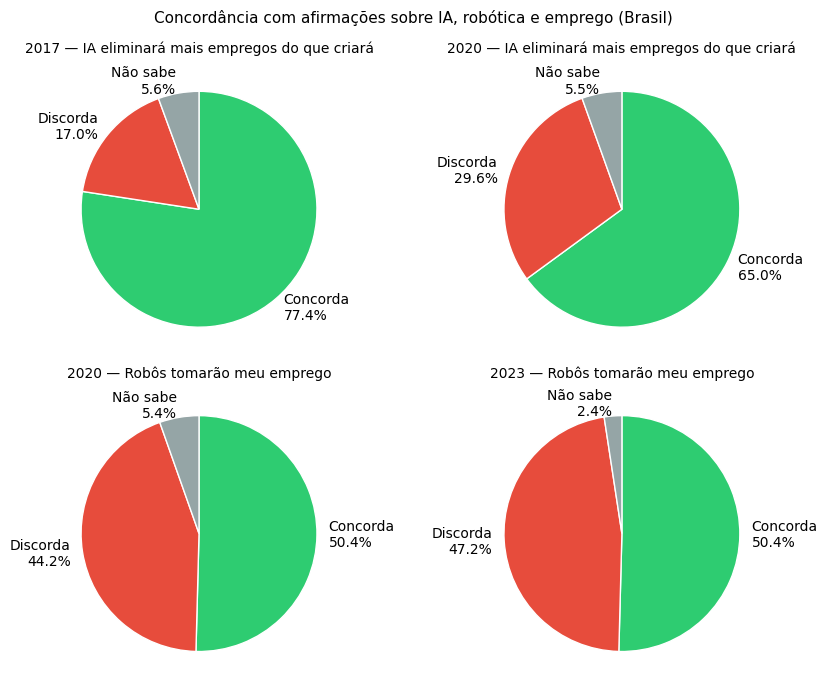

In [40]:
import matplotlib.pyplot as plt

CORES = {
    "Concorda": "#2ecc71",
    "Discorda": "#e74c3c",
    "Não sabe": "#95a5a6",
}

graficos = [
    (2017, resumo_2017, "IA eliminará mais empregos do que criará"),
    (2020, resumo_2020, "IA eliminará mais empregos do que criará"),
    (2020, resumo_robos_2020, "Robôs tomarão meu emprego"),
    (2023, resumo_robos_2023, "Robôs tomarão meu emprego"),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))

for ax, (ano, resumo, tema) in zip(axes.flat, graficos):
    categorias = resumo.index.tolist()
    valores = resumo["quantidade"]
    percentuais = resumo["percentual"]
    rotulos = [f"{cat}\n{pct}%" for cat, pct in zip(categorias, percentuais)]

    ax.pie(
        valores,
        labels=rotulos,
        colors=[CORES[cat] for cat in categorias],
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
    )
    ax.set_title(f"{ano} — {tema}", fontsize=10)

fig.suptitle("Concordância com afirmações sobre IA, robótica e emprego (Brasil)", fontsize=11)
plt.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0.1)
plt.show()